In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Data Cleaning

In [ ]:
#Features of the dataset
df = pd.read_csv('dataset.csv')
len(df)

#Sorts caffeine intake into categorical data 
df['caffeine_groups'] = pd.cut(df['caffeine_intake_cups'],
                               bins = 3,
                               labels = ['0-1 Cups', '2 Cups', '3-4 Cups'])
list(df.columns)

['user_id',
 'age',
 'gender',
 'occupation',
 'daily_screen_time_hours',
 'phone_usage_before_sleep_minutes',
 'sleep_duration_hours',
 'sleep_quality_score',
 'stress_level',
 'caffeine_intake_cups',
 'physical_activity_minutes',
 'notifications_received_per_day',
 'mental_fatigue_score',
 'caffeine_groups']

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   user_id                           15000 non-null  int64   
 1   age                               15000 non-null  int64   
 2   gender                            15000 non-null  str     
 3   occupation                        15000 non-null  str     
 4   daily_screen_time_hours           15000 non-null  float64 
 5   phone_usage_before_sleep_minutes  15000 non-null  int64   
 6   sleep_duration_hours              15000 non-null  float64 
 7   sleep_quality_score               15000 non-null  float64 
 8   stress_level                      15000 non-null  float64 
 9   caffeine_intake_cups              15000 non-null  int64   
 10  physical_activity_minutes         15000 non-null  int64   
 11  notifications_received_per_day    15000 non-null  int64   
 12  m

## Statistical Analysis

- H0: Occupation has no impact on sleep quality  
- HA: Occupation does have an impact on sleep quality
- alpha = 0.05

In [6]:
manager = df[df['occupation'] == 'Manager']
doctor = df[df['occupation'] == 'Doctor']
swe = df[df['occupation'] == 'Software Engineer']
freelancer = df[df['occupation'] == 'Freelancer']
student = df[df['occupation'] == 'Student']
researcher = df[df['occupation'] == 'Researcher']
designer = df[df['occupation'] == 'Designer']
teacher = df[df['occupation'] == 'Teacher']

from scipy.stats import f_oneway

f_stat, p_value = f_oneway(
    manager['sleep_quality_score'],
    doctor['sleep_quality_score'],
    swe['sleep_quality_score'],
    freelancer['sleep_quality_score'],
    student['sleep_quality_score'],
    researcher['sleep_quality_score'],
    designer['sleep_quality_score'],
    teacher['sleep_quality_score'], )

print(p_value)

0.0037833475370639565


By p-value analysis alone, we reject the null hypothesis and say that occupation has an effect on sleep quality.

C:\Users\ryanl\AppData\Local\Temp\ipykernel_13524\2176801048.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels = labels)


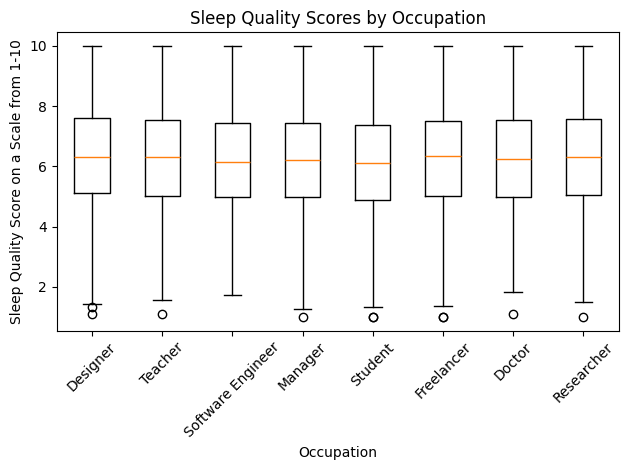

In [7]:
#Graphing
#Taking a look at sleep quality distributions by occupation

groups = [df[df['occupation'] == occ]['sleep_quality_score'] for occ in df['occupation'].unique()]
labels = df['occupation'].unique()

plt.boxplot(groups, labels = labels)
plt.title('Sleep Quality Scores by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Sleep Quality Score on a Scale from 1-10')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
from pingouin import anova

anova(data = df, dv = 'sleep_quality_score', between = 'occupation', detailed = True)

,Source,SS,DF,MS,F,p_unc,np2
0,occupation,61.617342,7,8.802477,3.000328,0.003783,0.001399
1,Within,43984.104632,14992,2.933838,NaN,NaN,NaN


From the distribution of sleep quality scores by occupation, it is difficult to observe the statistical significance shown by the p-value due to the extremely large samplesize of the dataset. Additionally a more detailed anova test shows a partial eta^2 value (effect size of significance) of 0.0014 which is an extremeley small significant difference.

Test Screen Time vs. Sleep Quality

- H0: Screen Time has no effect on Sleep Quality
- HA: Screen Time has a negative effect on Sleep Quality

- alpha = 0.05

In [ ]:
from scipy import stats

r, p_value = stats.pearsonr(df['daily_screen_time_hours'], df['sleep_quality_score'])
print(r, p_value)

-0.7465309918518426 0.0


From the pearson correlation assessment, we conclude that screen time and sleep quality have a strong negative correlation with a strong significance level meaning that as screen time increases, sleep quality decreases.

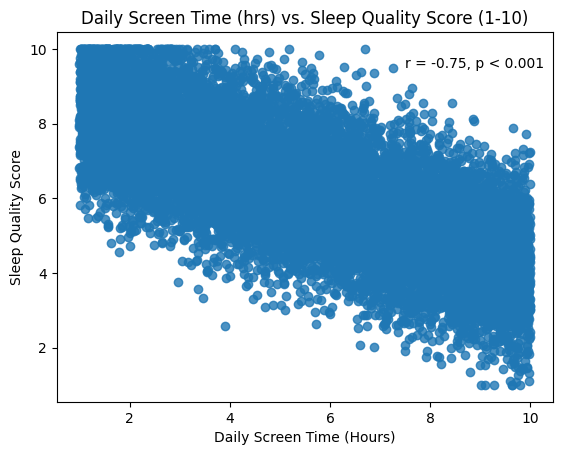

In [22]:
import seaborn as sns

sns.regplot(x = 'daily_screen_time_hours', y = 'sleep_quality_score', data = df)

plt.title('Daily Screen Time (hrs) vs. Sleep Quality Score (1-10)')
plt.xlabel('Daily Screen Time (Hours)')
plt.ylabel('Sleep Quality Score')
plt.text(x=df['daily_screen_time_hours'].max() * 0.75, 
         y=df['sleep_quality_score'].max() * 0.95,
         s='r = -0.75, p < 0.001')
plt.show()
